<a href="https://colab.research.google.com/github/jhlopesalves/eda_humanidades/blob/main/encontro_8/enc_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Encontro 8: Correlação e associação entre variáveis

**Instrutor**: Jhonatan Lopes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

In [ ]:
arxiv_url = (
    "https://raw.githubusercontent.com/jhlopesalves/"
    "eda_humanidades/refs/heads/main/"
    "encontro_5/data/arxiv_eda_papers.csv"
)

arxiv_df = pd.read_csv(
    arxiv_url,
    dtype={"paper_id": "string"},
)

In [ ]:
arxiv_df.sample(
    n=5,
    random_state=42,
)

,paper_id,title,abstract_preview,primary_category,category_label,top_level,top_level_label,year,decade,n_authors,n_versions,n_categories,title_n_words,abstract_n_words,has_doi,has_journal_ref
238,2108.10682,Hybrid deep learning methods for phenotype pre...,Identifying patient cohorts from clinical note...,cs.CL,Computational Linguistics / NLP,cs,Computer Science,2021,2020s,3,3,2,10,200,True,False
1157,2204.12495,Enhancing Privacy against Inversion Attacks in...,Federated learning reduces the risk of informa...,cs.LG,Machine Learning,cs,Computer Science,2022,2020s,5,1,4,13,196,False,False
2396,2002.02779,Generating Digital Twins with Multiple Scleros...,Multiple Sclerosis (MS) is a neurodegenerative...,stat.ML,Statistical Machine Learning,stat,Statistics,2020,2020s,6,2,3,10,130,False,False
51,2212.03830,A Hierarchical Deep Reinforcement Learning Fra...,Unmanned combat air vehicle (UCAV) combat is a...,cs.AI,Artificial Intelligence,cs,Computer Science,2022,2020s,5,1,3,11,208,False,False
2178,2403.08646,Covariance Fitting Interferometric Phase Linki...,Interferometric phase linking (IPL) has become...,stat.AP,Applied Statistics,stat,Statistics,2024,2020s,5,1,1,10,164,False,False


In [ ]:
colunas_numericas = arxiv_df.select_dtypes(include="number")

colunas_numericas.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3387.0,2022.854739,1.732267,2020.0,2021.0,2023.0,2024.0,2025.0
n_authors,3387.0,4.202834,4.305577,1.0,2.0,4.0,5.0,182.0
n_versions,3387.0,1.695010,0.992284,1.0,1.0,1.0,2.0,8.0
n_categories,3387.0,2.184529,1.113424,1.0,1.0,2.0,3.0,8.0
title_n_words,3387.0,9.912902,3.524000,2.0,7.0,10.0,12.0,32.0
abstract_n_words,3387.0,172.085326,47.876997,38.0,139.0,171.0,204.0,310.0


## Correlação

Os gráficos de dispersão permitem examinar visualmente como duas variáveis
quantitativas variam em conjunto. Coeficientes de correlação resumem
numericamente aspectos específicos dessa associação.

Convém distinguir três conceitos:

- **associação** refere-se, de forma geral, à variação conjunta entre variáveis;
- **correlação** refere-se aqui a medidas numéricas de tipos específicos de
  associação;
- **causalidade** envolve uma relação causal entre variáveis e não pode ser
  estabelecida apenas a partir de um coeficiente de correlação.

### Correlação de Pearson

O coeficiente de correlação de Pearson, representado por $r$, resume a direção
e a magnitude da associação linear entre duas variáveis quantitativas:

$$
-1 \leq r \leq 1
$$

Valores positivos indicam associações lineares positivas; valores negativos,
associações lineares negativas. Quanto mais próximo de zero estiver $r$, menor
será a magnitude da associação linear.

O qualificativo **linear** é fundamental: um coeficiente próximo de zero não
implica ausência de outros padrões de associação.

A interpretação de $r$ deve, portanto, ser acompanhada pela inspeção da
distribuição conjunta das observações.

In [ ]:
title_abstract_pearson = stats.pearsonr(
    x=arxiv_df["title_n_words"],
    y=arxiv_df["abstract_n_words"],
)

title_abstract_pearson

PearsonRResult(statistic=np.float64(0.1561756265600617), pvalue=np.float64(6.136895876373161e-20))

`stats.pearsonr()` retorna um objeto com dois resultados. O atributo
`statistic` contém o coeficiente de correlação de Pearson.

O atributo `pvalue` resulta de um teste de hipótese sobre a correlação
populacional e não será utilizado nesta análise descritiva.

In [ ]:
print(
    f"Pearson r: {title_abstract_pearson.statistic:.3f}"
)

Pearson r: 0.156


O coeficiente é positivo, mas sua magnitude é pequena.

Esse resultado é consistente com o gráfico de dispersão: observa-se uma
discreta tendência positiva, acompanhada por ampla dispersão entre as
observações.

O coeficiente resume a associação linear em um único número; ele não substitui
a inspeção do gráfico.

In [ ]:
authors_abstract_pearson = stats.pearsonr(
    x=arxiv_df["n_authors"],
    y=arxiv_df["abstract_n_words"],
)

print(
    f"Pearson r: {authors_abstract_pearson.statistic:.3f}"
)

Pearson r: 0.084


### Sensibilidade a uma observação extrema

Como o coeficiente de Pearson utiliza os valores numéricos originais, podemos
examinar quanto o resultado depende da observação com 182 autores.

A comparação é uma análise de sensibilidade: o coeficiente será recalculado
temporariamente sem essa observação, sem tratá-la como erro ou excluí-la da
análise principal.

In [ ]:
# Localiza a linha com a maior contagem de autores.
max_authors_idx = arxiv_df["n_authors"].idxmax()

# Cria um conjunto temporário sem essa observação para a análise de sensibilidade.
without_max_authors = arxiv_df.drop(
    index=max_authors_idx
)

authors_abstract_pearson_without_max = stats.pearsonr(
    x=without_max_authors["n_authors"],
    y=without_max_authors["abstract_n_words"],
)

print(
    f"Com todos os artigos: "
    f"{authors_abstract_pearson.statistic:.3f}"
)

print(
    f"Sem o artigo com 182 autores: "
    f"{authors_abstract_pearson_without_max.statistic:.3f}"
)

Com todos os artigos: 0.084
Sem o artigo com 182 autores: 0.099


O coeficiente passa de $r = 0.084$ para $r = 0.099$. A diferença é pequena, e
a descrição da associação linear permanece praticamente inalterada.

A comparação indica que, neste caso, o coeficiente de Pearson apresenta pouca
sensibilidade à observação com 182 autores. Como essa observação é válida, ela
permanece na análise principal.

### Correlação de Spearman

O coeficiente de Pearson utiliza os valores numéricos das variáveis e resume
uma associação linear. A correlação de Spearman, representada por $\rho$
(*rho*), utiliza seus **postos** (*ranks*) na ordenação.

Spearman resume associações monotônicas: valores maiores de uma variável tendem
a corresponder a valores sistematicamente maiores ou menores da outra, sem que
essa relação precise ser linear.

Assim como Pearson:

$$
-1 \leq \rho \leq 1
$$

In [ ]:
author_ranks = arxiv_df["n_authors"].rank(
    method="average"
)

author_rank_df = pd.DataFrame(
    data={
        "n_authors": arxiv_df["n_authors"],
        "rank": author_ranks,
    }
)

author_rank_df.sort_values(
    by="n_authors",
    ascending=False,
).head(10)

,n_authors,rank
610,182,3387.0
493,76,3386.0
449,45,3385.0
1655,33,3383.5
1349,33,3383.5
343,27,3382.0
1618,25,3380.5
3,25,3380.5
693,24,3378.5
935,24,3378.5


Por padrão, `Series.rank()` atribui o menor valor ao menor posto e o maior
valor ao maior posto. Por isso, o artigo com 182 autores recebe o posto 3387.

Empates exigem uma regra adicional. Com `method="average"`, observações com o
mesmo valor recebem a média dos postos que ocupariam.

Os dois artigos com 33 autores, por exemplo, ocupariam os postos 3383 e 3384:

$$
\frac{3383 + 3384}{2} = 3383.5
$$

Ambos recebem, portanto, o posto `3383.5`.

A magnitude de `182` deixa de ser utilizada diretamente; para o cálculo,
importa sua posição relativa na ordenação.

In [ ]:
abstract_length_ranks = arxiv_df[
    "abstract_n_words"
].rank(
    method="average"
)

Com as duas variáveis substituídas por seus postos, a correlação de Spearman
corresponde à correlação de Pearson calculada entre esses postos (rankings).

In [ ]:
pearson_between_ranks = stats.pearsonr(
    author_ranks,
    abstract_length_ranks,
)

print(
    f"Pearson entre os ranks: {pearson_between_ranks.statistic:.3f}"
)

Pearson entre os ranks: 0.111


`stats.spearmanr()` executa diretamente o ranqueamento das duas variáveis e o
cálculo da correlação entre seus postos.

In [ ]:
authors_abstract_spearman = stats.spearmanr(
    a=arxiv_df["n_authors"],
    b=arxiv_df["abstract_n_words"],
)

print(
    f"Pearson entre os ranks: {pearson_between_ranks.statistic:.3f}"
)

print(
    f"Spearman ρ: {authors_abstract_spearman.statistic:.3f}"
)

Pearson entre os ranks: 0.111
Spearman ρ: 0.111


In [ ]:
print(
    f"Pearson r: {authors_abstract_pearson.statistic:.3f}"
)

print(
    f"Spearman ρ: {authors_abstract_spearman.statistic:.3f}"
)

Pearson r: 0.084
Spearman ρ: 0.111


Os dois coeficientes são positivos e de pequena magnitude, mas não são
idênticos.

Pearson depende das distâncias entre os valores na escala original e resume a
associação linear. Spearman depende dos postos das observações, e não dessas
distâncias, e resume a associação monotônica.

Neste conjunto de dados, a diferença entre os coeficientes é pequena e não
modifica substancialmente a descrição da relação.

In [ ]:
authors_abstract_spearman_without_max = stats.spearmanr(
    without_max_authors["n_authors"],
    without_max_authors["abstract_n_words"],
)

print(
    f"Com todos os artigos: "
    f"{authors_abstract_spearman.statistic:.4f}"
)

print(
    f"Sem o artigo com 182 autores: "
    f"{authors_abstract_spearman_without_max.statistic:.4f}"
)

Com todos os artigos: 0.1112
Sem o artigo com 182 autores: 0.1106


A retirada temporária do artigo com 182 autores produz apenas uma pequena
alteração no coeficiente de Spearman.

A magnitude numérica de `182` não entra diretamente no cálculo; a observação é representada por seu posto (ranking).

Spearman é, portanto, menos sensível à magnitude de valores extremos, mas não é
imune a observações influentes. Uma observação pode ocupar um posto extremo e
ainda contrariar o padrão de ordenação das demais.

A escolha entre Pearson e Spearman depende do tipo de associação que se deseja
resumir e da informação da escala original que se pretende preservar.

## Matriz de correlação

Uma matriz de correlação reúne os coeficientes calculados para todos os pares
de variáveis consideradas na análise.

Neste caso, cada célula contém uma correlação de Spearman entre duas variáveis
quantitativas do conjunto de dados do arXiv.

In [ ]:
arxiv_spearman_matrix = colunas_numericas.corr(
    method="spearman"
)

arxiv_spearman_matrix.round(2)

,year,n_authors,n_versions,n_categories,title_n_words,abstract_n_words
year,1.00,0.08,-0.02,-0.05,0.05,0.04
n_authors,0.08,1.00,0.07,-0.05,0.05,0.11
n_versions,-0.02,0.07,1.00,0.13,-0.08,0.03
n_categories,-0.05,-0.05,0.13,1.00,-0.12,-0.05
title_n_words,0.05,0.05,-0.08,-0.12,1.00,0.15
abstract_n_words,0.04,0.11,0.03,-0.05,0.15,1.00


Cada célula contém a correlação entre um par de variáveis.

A diagonal principal contém apenas valores iguais a `1`, pois cada variável
apresenta correlação perfeita consigo mesma.

A matriz também é simétrica:

$$
\rho(X,Y) = \rho(Y,X)
$$

Os valores acima e abaixo da diagonal, portanto, se repetem.

### Visualização da matriz com um heatmap

Um heatmap associa cada valor da matriz a uma cor, permitindo comparar
visualmente os coeficientes entre diferentes pares de variáveis.

`sns.heatmap()` aceita diretamente uma matriz ou um `DataFrame` bidimensional.

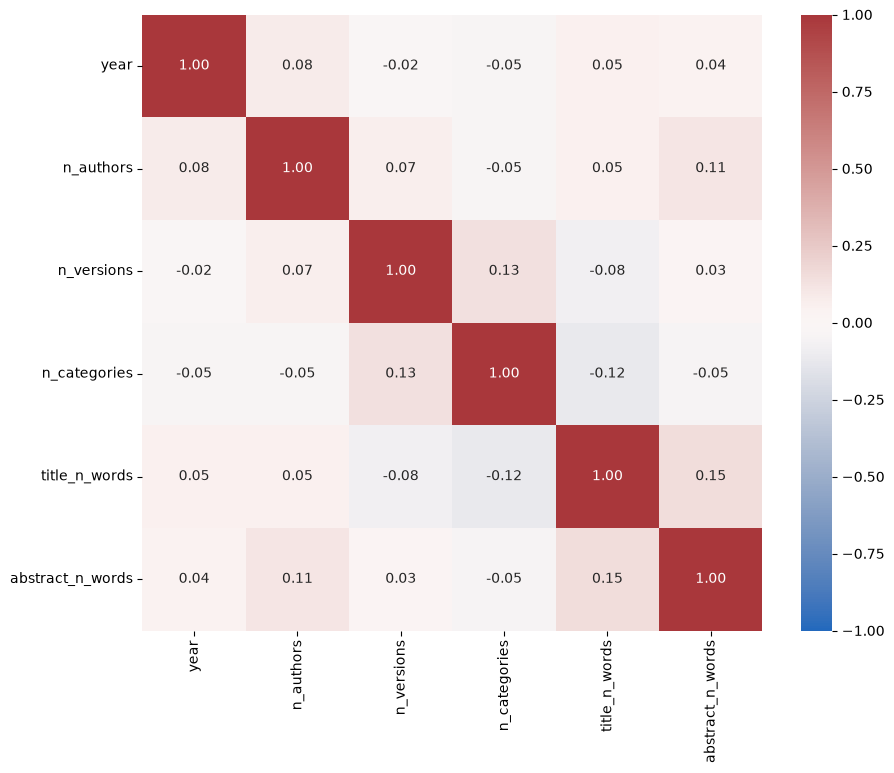

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    data=arxiv_spearman_matrix,

    # Mantém uma escala de cores comparável entre matrizes de correlação.
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",

    # Exibe o coeficiente em cada célula com duas casas decimais.
    annot=True,
    fmt=".2f",

    ax=ax,
)

plt.show()

## Um segundo conjunto de dados: Gapminder

A matriz de correlação do arXiv apresentou, em geral, associações relativamente
pequenas entre as variáveis analisadas.

O conjunto de dados Gapminder permite examinar o mesmo tipo de relação em um
conjunto de observações com características distintas.

In [ ]:
gapminder_url = (
    "https://raw.githubusercontent.com/jhlopesalves/eda_humanidades/"
    "refs/heads/main/encontro_4/data/gapminderDataFiveYear.csv"
)

gapminder_df = pd.read_csv(
    gapminder_url
)

gapminder_2007 = gapminder_df[
    gapminder_df["year"] == 2007
]

gapminder_2007.sample(
    n=10,
    random_state=42,
)

,country,year,pop,continent,lifeExp,gdpPercap
1583,Turkey,2007,71158647.0,Europe,71.777,8458.276384
239,Cameroon,2007,17696293.0,Africa,50.430,2042.095240
983,Mauritius,2007,1250882.0,Africa,72.801,10956.991120
1163,Oman,2007,3204897.0,Asia,75.640,22316.192870
683,Hungary,2007,9956108.0,Europe,73.338,18008.944440
155,Bosnia and Herzegovina,2007,4552198.0,Europe,74.852,7446.298803
1187,Panama,2007,3242173.0,Americas,75.537,9809.185636
791,Jamaica,2007,2780132.0,Americas,72.567,7320.880262
803,Japan,2007,127467972.0,Asia,82.603,31656.068060
227,Cambodia,2007,14131858.0,Asia,59.723,1713.778686


O conjunto completo contém observações dos mesmos países em diferentes anos.
Para a matriz de correlação, manteremos todas essas observações, incluindo
`year` entre as variáveis numéricas.

A variável `year` merece uma interpretação particular: embora seja numérica,
ela representa tempo, e não uma medida quantitativa do mesmo tipo que
`lifeExp`, `pop` ou `gdpPercap`.

In [ ]:
gapminder_df.loc[
    gapminder_df["country"] == "Brazil",
    [
        "country",
        "year",
        "lifeExp",
        "gdpPercap",
    ],
]

,country,year,lifeExp,gdpPercap
168,Brazil,1952,50.917,2108.944355
169,Brazil,1957,53.285,2487.365989
170,Brazil,1962,55.665,3336.585802
171,Brazil,1967,57.632,3429.864357
172,Brazil,1972,59.504,4985.711467
173,Brazil,1977,61.489,6660.118654
174,Brazil,1982,63.336,7030.835878
175,Brazil,1987,65.205,7807.095818
176,Brazil,1992,67.057,6950.283021
177,Brazil,1997,69.388,7957.980824


In [ ]:
gapminder_spearman_matrix = (
    gapminder_df
    .select_dtypes(include="number")
    .corr(method="spearman")
)

gapminder_spearman_matrix.round(2)

,year,pop,lifeExp,gdpPercap
year,1.00,0.22,0.45,0.23
pop,0.22,1.00,0.18,0.05
lifeExp,0.45,0.18,1.00,0.83
gdpPercap,0.23,0.05,0.83,1.00


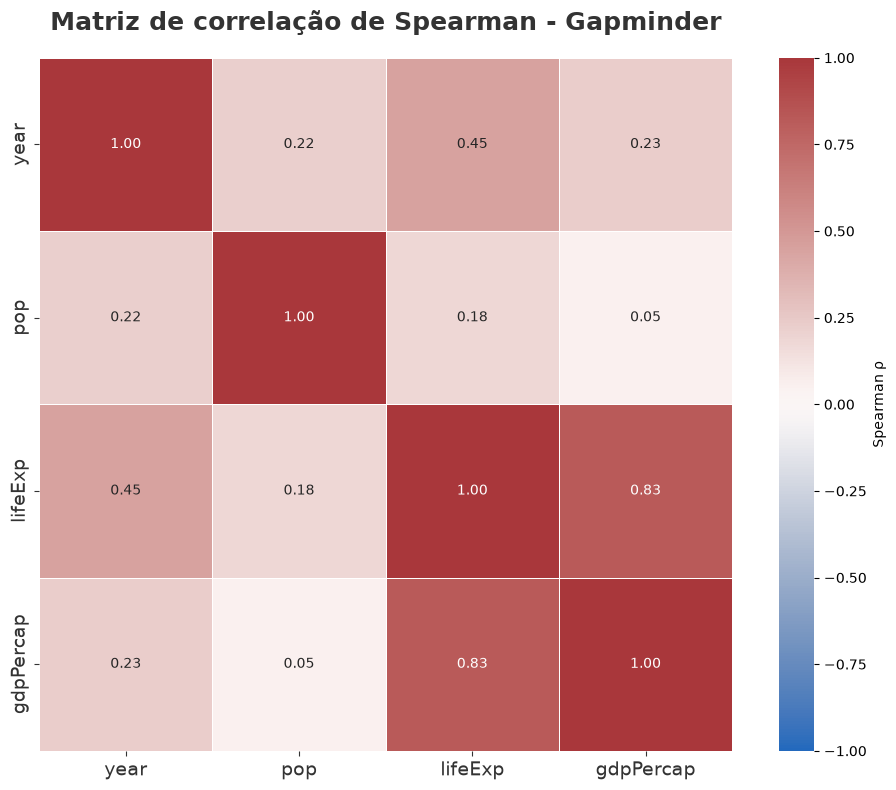

In [ ]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

sns.heatmap(
    data=gapminder_spearman_matrix,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="vlag",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={
        "label": "Spearman ρ",
    },
    square=True,
    ax=ax,
)

ax.set_title(
    "Matriz de correlação de Spearman - Gapminder",
    fontsize=18,
    fontweight="bold",
    pad=20,
    color="#333333",
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=14,
    colors="#333333",
)

plt.tight_layout()
plt.show()

A matriz reúne observações de vários países ao longo de diferentes anos.
Algumas associações podem, portanto, refletir tanto diferenças entre países
quanto mudanças ocorridas ao longo do tempo.

`year` também exige uma leitura específica. Sua correlação com outra variável
indica se valores maiores dessa variável tendem a ocorrer em anos mais recentes
ou mais antigos; o coeficiente não atribui ao tempo o mesmo significado
substantivo das demais medidas.